In [2]:
#Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np
import os
import h5py

current_dir = os.getcwd()

#Loading GT and SUB Data
try:
    #Output/GT_h5/groundtruth.h5
    folder_dir = "output/GT_h5"
    h5_file_path = os.path.join(current_dir, "output", "GT_h5", "groundtruth.h5")
    gt_data  = pd.read_hdf(h5_file_path, "/data")
    print("Voltage Data Loading done!")
    gt_spikes = pd.read_hdf(h5_file_path, "/spikes_raw")
    print("Spike Data Loading done!")

    #Common to both GT and SUB
    cfg  = pd.read_hdf(h5_file_path, "/network_config")
    print("Network configuration Loading done!")
    tmap = pd.read_hdf(h5_file_path, "/trial_map")
    print("Trial Map Loading done!")

    sub_data = gt_data.copy() # Placeholder for SUB data loading, replace with actual SUB data loading code
    sub_spikes = gt_spikes.copy() # Placeholder for SUB spikes loading, replace with actual SUB spikes loading code

    import json
    with open("output/GT/network_config.json", "r") as f:
        net_config = json.load(f)
    truth_table = net_config["truth_table"]

    patterns = tmap["case"].unique().tolist()

except Exception as e:
    print(f"Data laoding failed as {e}")


Voltage Data Loading done!
Spike Data Loading done!
Network configuration Loading done!
Trial Map Loading done!


In [3]:
try:
    # verify GT and SUB have same number of trials
    assert len(gt_data["trial_id"].unique()) == len(sub_data["trial_id"].unique())

    # verify pattern distribution is identical
    assert (gt_data.groupby("case").size() == sub_data.groupby("case").size()).all()

except Exception as e:
    print(e)

In [4]:
#Helper Functions
def get_neurons(cfg, role=None, input_channel=None):
    #     role="output"                 - ["E"]
    #     role="input"                  - ["PyrIn_A","PyrIn_B1","PyrIn_B2"]
    #     role=["input","interneuron",
    #           "intermediate","output"]- all 8 active neurons
    #     role="all"                    - all 35 labels
    #     input_channel=2               - ["PyrIn_B1","PyrIn_B2"]
    result = cfg
    if role!= None and role!= "all":
        if isinstance(role, list):
            result = result[result["role"].isin(role)]
        else:
            result = result[result["role"] == role]

    if input_channel!= None:
        result = result[result["input_channel"] == input_channel]

    return result["label"].tolist()
        
def get_spiking_neurons(cfg, data, label = None):
    #     checks _spike cols in data at runtime
    #     returns labels where spike col sum > 0
    spiking = []

    if label == None:
        for _ in cfg["label"]:
            if data[f"{_}_spike"].sum()>0:
                spiking.append(_)
    else:
        if data[label].sum() > 0:
            spiking.append(label)
       
    return spiking
        
def get_spike_cols(cfg, data, role =None):
   #     calls get_spiking_neurons()
   #     returns ["{label}_spike", ...] for spiking neurons
   columns = []
   
   if role == None:
        for label in get_spiking_neurons(cfg,data):
            columns.append(f"{label}_spike")
    
   else:
        for label in get_neurons(cfg, role=role):
            columns.append(f"{label}_spike")
    
   return columns

def get_vm_cols(cfg, scope="all"):
    #     scope="all"    - all 35 _vm column names
    #     scope="active" - 8 active neurons _vm column names
    roles = []
    if(scope == "active"):
        for _,row in cfg.iterrows():
            if row["role"] != "extended_network":
                roles.append(f"{row['label']}_vm")
    else:
        for _,row in cfg.iterrows():
            roles.append(f"{row['label']}_vm")
    return roles

def get_trial(data, trial_id):
    return data[data["trial_id"] == trial_id]

def get_trials_by_pattern(data, pattern):
    #     returns list of DataFrames where case == pattern
    #     10 DataFrames per pattern (one per rep)
    result = []
    unique = data["rep"].unique()
    for u in unique:
        filtered = data[(data["case"] == pattern) & (data["rep"] == u)]
        result.append(filtered)

    return result

def load_metadata(h5_path):
    #     reads /metadata attrs via h5py
    #     returns plain dict:
    #       {"fs_hz": 1000.0, "t_total_ms": 4000.0, "n_trials": 40,
    #        "trial_len_ms": 100.0, "n_neurons_total": 35, "n_neurons_spiking": 8}
    with h5py.File(h5_path,"r") as f:
        metadata = dict(f["/metadata"].attrs)
    
    return metadata

In [6]:
#Behavioural Metrics
#This metric needs the output neuron

# Get output neuron spike column and trial length from metadata
role_behavioural = "output"
label = get_spike_cols(cfg, gt_data, role=role_behavioural)[0]
meta = load_metadata(h5_file_path)
trial_len = meta["trial_len_ms"]

def compute_confusion_matrix(data,pattern):
    """
    For a given pattern, loops over all 10 repetitions and checks
    whether E fired within the trial window. Classifies each trial
    as TP, FN, TN or FP based on the truth table.
    """
    trials = get_trials_by_pattern(data,pattern)
    TP, FN, TN, FP = 0, 0, 0, 0
    for t in trials:
        #print(t["t_in_trial"])
        window = t[t["t_in_trial"] <= trial_len]
        fired = window[label].sum() > 0
        want = truth_table[f"XOR_{pattern}"]["expected_output"]
        have = 1 if fired else 0

        if want == 1 and have == 1:
            TP += 1
        elif want == 1 and have == 0:
            FN += 1
        elif want == 0 and have == 0:
            TN += 1
        else:
            FP += 1

    return TP,FN,TN,FP
        
def all_patterns(data,patterns):
    """
    Runs compute_confusion_matrix() for all 4 XOR patterns.
    Patterns derived from tmap — not hardcoded.
    Returns a DataFrame with TP/FN/TN/FP and derived metrics per pattern.
    """     
    rows = []
    for p in patterns:
        tp,fn,tn,fp = compute_confusion_matrix(data,p)
        den = tp + fn + tn + fp
        rows.append({
            "Pattern": p,
            "TP": tp, "FN": fn, "TN": tn, "FP": fp,
            "Accuracy": (tp + tn) / den if den else 0.0,
            "Sensitivity": tp / (tp + fn) if (tp + fn) else 0.0,
            "Specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        })

    return pd.DataFrame(rows)

print(pd.DataFrame(truth_table))
gt_results = all_patterns(gt_data,patterns)
sub_results = all_patterns(sub_data,patterns)
print("Ground Truth:")
print(gt_results.to_string(index=False))
print("\nSubmission:")
print(sub_results.to_string(index=False))


                 XOR_00  XOR_01  XOR_10  XOR_11
input_A               0       0       1       1
input_B               0       1       0       1
expected_output       0       1       1       0
Ground Truth:
Pattern  TP  FN  TN  FP  Accuracy  Sensitivity  Specificity
     00   0   0  10   0       1.0          0.0          1.0
     11   0   0  10   0       1.0          0.0          1.0
     01  10   0   0   0       1.0          1.0          0.0
     10  10   0   0   0       1.0          1.0          0.0

Submission:
Pattern  TP  FN  TN  FP  Accuracy  Sensitivity  Specificity
     00   0   0  10   0       1.0          0.0          1.0
     11   0   0  10   0       1.0          0.0          1.0
     01  10   0   0   0       1.0          1.0          0.0
     10  10   0   0   0       1.0          1.0          0.0


In [ ]:
#Membrane Potential Visualization - Stitched Traces and Statistical Views

# Maximum trials to show in stitched view (None = all)
MAX_TRIALS_PER_PATTERN_STITCH = None

def _median_iqr_over_trials(trials, idxs, col):
    """
    Compute per-sample median and IQR across trials.
    Returns: (median, q25, q75) arrays of length TRIAL_LEN
    """
    if not idxs:
        return None, None, None

    mat = []
    for i in idxs:
        if i >= len(trials):
            continue
        vec = trials[i][col].to_numpy(float)
        if len(vec) >= trial_len:
            mat.append(vec[trial_len])

    if not mat:
        return None, None, None

    M = np.vstack(mat)
    med = np.nanmedian(M, axis=0)
    q25 = np.nanpercentile(M, 25, axis=0)
    q75 = np.nanpercentile(M, 75, axis=0)
    return med, q25, q75

def _stitch_series(trials, idxs, col, max_trials=None):
    """
    Concatenate trials end-to-end.
    Returns: (stitched_y, time_axis)
    """
    if not idxs:
        return np.array([]), np.array([])

    use = idxs if (max_trials is None) else idxs[:max_trials]
    chunks = []
    for i in use:
        vec = trials[i][col].to_numpy(float)[:trial_len]
        chunks.append(vec)

    if not chunks:
        return np.array([]), np.array([])

    y = np.concatenate(chunks)
    t = np.arange(y.size, dtype=float)
    return y, t

def _neuron_label(col):
    """Extract neuron name from column."""
    return col.replace("_membrane_potential", "")

# Generate visualizations for each pattern and neuron
for patt in patterns:
    common_ids = tmap[tmap["case"] == patt]["trial_id"].tolist()

    print(common_ids)
    for col in get_vm_cols(cfg, scope="active"):
        neuron = _neuron_label(col)

        # Compute statistics
        med_gt, q25_gt, q75_gt = _median_iqr_over_trials(get_trial(gt_data,trial_ids = common_ids), common_ids, col)
        med_sub, q25_sub, q75_sub = _median_iqr_over_trials(get_trial(sub_data,trial_ids = common_ids), common_ids, col)

        # Figure 1: GT stitched with median overlay
        y_gt, t_gt = _stitch_series(get_trial(gt_data,trial_ids = common_ids), common_ids, col, MAX_TRIALS_PER_PATTERN_STITCH)
        fig, ax = plt.subplots(figsize=(12, 3.2))

        if y_gt.size:
            ax.plot(t_gt, y_gt, lw=0.6, label="GT stitched", alpha=0.9)

        if med_gt is not None:
            reps = int(np.ceil(max(1, y_gt.size) / trial_len))
            med_tile = np.tile(med_gt, reps)[:max(1, y_gt.size)]
            ax.plot(np.arange(med_tile.size), med_tile, lw=1.6, linestyle="--",
                   label="GT median", alpha=0.9)

        ax.set_title(f"{neuron} — GT Stitched (pattern {patt}) with Median")
        ax.set_xlabel("Sample (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 2: SUB stitched with median overlay
        y_sub, t_sub = _stitch_series(get_trial(sub_data,trial_ids = common_ids), common_ids, col, MAX_TRIALS_PER_PATTERN_STITCH)
        fig, ax = plt.subplots(figsize=(12, 3.2))

        if y_sub.size:
            ax.plot(t_sub, y_sub, lw=0.6, color="tab:orange", label="SUB stitched", alpha=0.9)

        if med_sub is not None:
            reps = int(np.ceil(max(1, y_sub.size) / trial_len))
            med_tile = np.tile(med_sub, reps)[:max(1, y_sub.size)]
            ax.plot(np.arange(med_tile.size), med_tile, lw=1.6, linestyle="--",
                   color="tab:blue", label="SUB median", alpha=0.9)

        ax.set_title(f"{neuron} — SUB Stitched (pattern {patt}) with Median")
        ax.set_xlabel("Sample (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 3: GT Median ± IQR
        x = np.arange(trial_len)
        fig, ax = plt.subplots(figsize=(10, 3.0))

        if med_gt is not None:
            ax.plot(x, med_gt, lw=2.0, label="GT median")
            if (q25_gt is not None) and (q75_gt is not None):
                ax.fill_between(x, q25_gt, q75_gt, alpha=0.25, label="GT IQR")

        ax.set_title(f"{neuron} — Median ± IQR (GT) — Pattern {patt}")
        ax.set_xlabel("Time within trial (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 4: SUB Median ± IQR
        fig, ax = plt.subplots(figsize=(10, 3.0))

        if med_sub is not None:
            ax.plot(x, med_sub, lw=2.0, color="tab:orange", label="SUB median")
            if (q25_sub is not None) and (q75_sub is not None):
                ax.fill_between(x, q25_sub, q75_sub, alpha=0.25, color="tab:orange", label="SUB IQR")

        ax.set_title(f"{neuron} — Median ± IQR (SUB) — Pattern {patt}")
        ax.set_xlabel("Time within trial (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()


[0, 4, 8, 12, 16, 20, 24, 28, 32, 36]


TypeError: get_trial() got an unexpected keyword argument 'trial_ids'

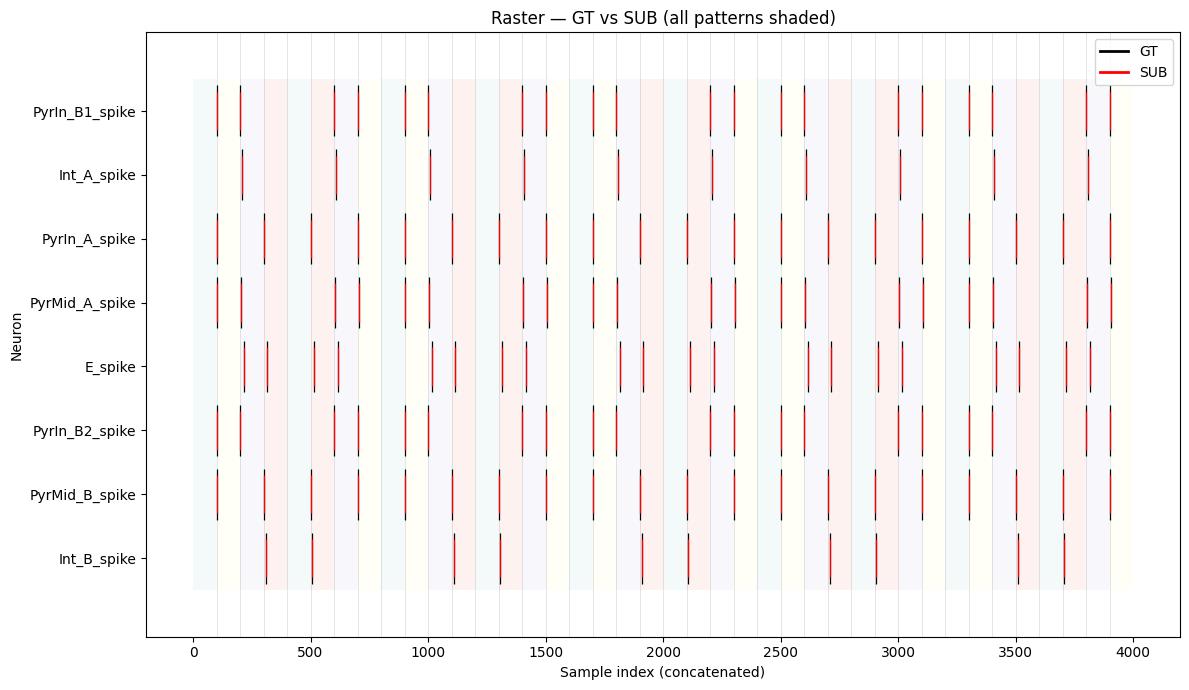

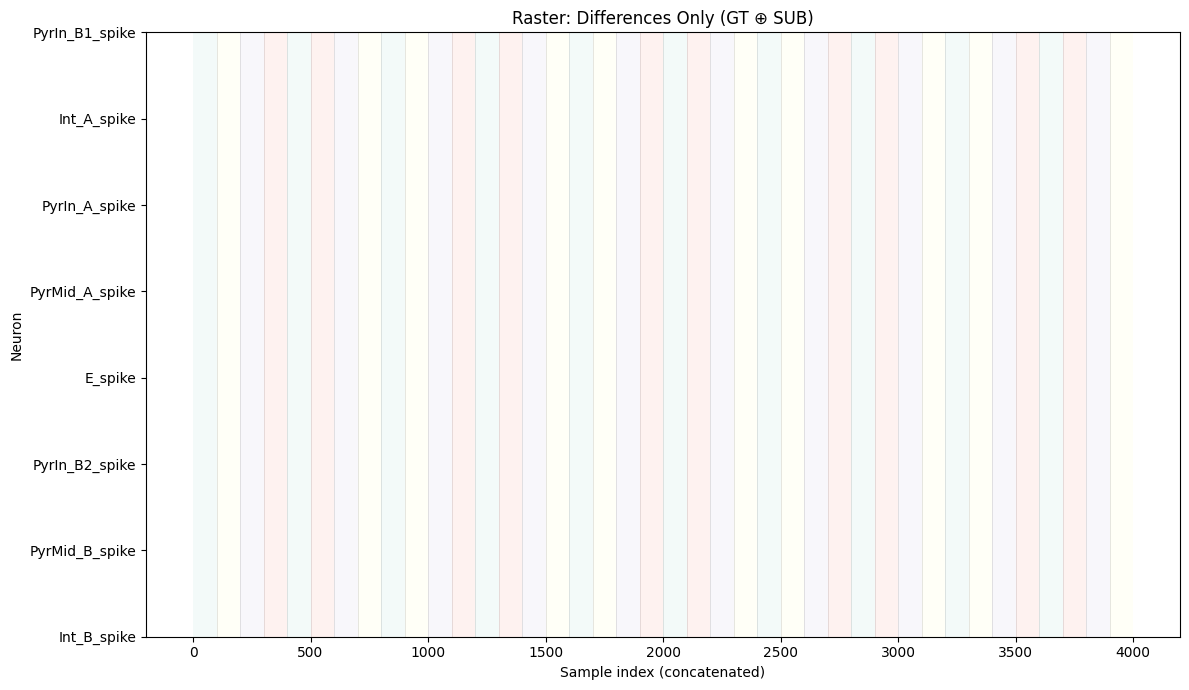


Jaccard similarity per neuron:
  Int_B_spike        1.000
  PyrMid_B_spike     1.000
  PyrIn_B2_spike     1.000
  E_spike            1.000
  PyrMid_A_spike     1.000
  PyrIn_A_spike      1.000
  Int_A_spike        1.000
  PyrIn_B1_spike     1.000
Mean Jaccard: 1.000

Difference counts (GT⊕SUB) per neuron:
  Int_B_spike        0
  PyrMid_B_spike     0
  PyrIn_B2_spike     0
  E_spike            0
  PyrMid_A_spike     0
  PyrIn_A_spike      0
  Int_A_spike        0
  PyrIn_B1_spike     0

Mean Jaccard by pattern:
  pattern 00: 1.000
  pattern 11: 1.000
  pattern 01: 1.000
  pattern 10: 1.000


In [14]:
#Raster Plot Visualization - Compare GT vs SUB spike patterns
gt_spike_cols  = set(get_spike_cols(cfg, gt_data))
sub_spike_cols = set(get_spike_cols(cfg, sub_data))
spike_cols = list(gt_spike_cols | sub_spike_cols)
trial_len  = int(meta["trial_len_ms"])                   

gt  = gt_data.copy()
sub = sub_data.copy()

FILTER_PATTERN = None

# Align lengths
n_rows = min(len(gt), len(sub))
gt = gt.iloc[:n_rows].reset_index(drop=True)
sub = sub.iloc[:n_rows].reset_index(drop=True)

# Extract spike times
gt_times = [np.where(gt[c].to_numpy(dtype=int) == 1)[0] for c in spike_cols]
sb_times = [np.where(sub[c].to_numpy(dtype=int) == 1)[0] for c in spike_cols]
diff_times = [np.setxor1d(g, s) for g, s in zip(gt_times, sb_times)]

def add_pattern_bands(ax, df, trial_len=100, alpha=0.10):
    """Add colored background bands to indicate input patterns."""
    import matplotlib.cm as cm
    unique_patterns = tmap["case"].unique()
    color_list = cm.Set3.colors[:len(unique_patterns)]
    colors = dict(zip(unique_patterns, [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" for r,g,b in color_list]))
    last_tid = int(df["trial_id"].iloc[-1])
    for tid in range(last_tid + 1):
        block = df[df["trial_id"] == tid]
        if block.empty:
            continue
        start = int(block.index.min())
        pat = str(block["case"].iloc[0])
        rect = Rectangle((start, -0.5), trial_len, len(spike_cols),
                        color=colors.get(pat, "#dddddd"), alpha=alpha, lw=0)
        ax.add_patch(rect)

# Figure 1: Overlay raster (GT and SUB)
fig, ax = plt.subplots(figsize=(12, 7))

if FILTER_PATTERN is None:
    add_pattern_bands(ax, gt, trial_len=trial_len, alpha=0.10)

ax.eventplot(gt_times, orientation="horizontal", linelengths=0.8, linewidths=0.9, colors="black")
ax.eventplot(sb_times, orientation="horizontal", linelengths=0.6, linewidths=0.9, colors="red")

ax.set_yticks(np.arange(len(spike_cols)))
ax.set_yticklabels(spike_cols)
ax.set_xlabel("Sample index (concatenated)")
ax.set_ylabel("Neuron")
ttl = "Raster — GT vs SUB" + (f" (pattern {FILTER_PATTERN})" if FILTER_PATTERN else " (all patterns shaded)")
ax.set_title(ttl)

# Legend
handles = [Line2D([0],[0], color="black", lw=2, label="GT"),
           Line2D([0],[0], color="red", lw=2, label="SUB")]
ax.legend(handles=handles, loc="upper right")

# Trial separators
total_trials = int(np.ceil(n_rows / trial_len))
for k in range(1, total_trials):
    ax.axvline(k * trial_len, color="0.85", lw=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Figure 2: Differences-only raster
fig, ax = plt.subplots(figsize=(12, 7))

if FILTER_PATTERN is None:
    add_pattern_bands(ax, gt, trial_len=trial_len, alpha=0.10)

ax.eventplot(diff_times, orientation="horizontal", linelengths=0.8, linewidths=0.9, colors="purple")
ax.set_yticks(np.arange(len(spike_cols)))
ax.set_yticklabels(spike_cols)
ax.set_xlabel("Sample index (concatenated)")
ax.set_ylabel("Neuron")
ax.set_title("Raster: Differences Only (GT ⊕ SUB)" + (f" (pattern {FILTER_PATTERN})" if FILTER_PATTERN else ""))

for k in range(1, total_trials):
    ax.axvline(k * trial_len, color="0.85", lw=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Numeric insights
def jaccard(a_idx, b_idx):
    """Compute Jaccard similarity between two spike index arrays."""
    if len(a_idx) == 0 and len(b_idx) == 0:
        return 1.0
    if len(a_idx) == 0 or len(b_idx) == 0:
        return 0.0
    inter = len(np.intersect1d(a_idx, b_idx))
    uni = len(np.union1d(a_idx, b_idx))
    return inter / uni if uni > 0 else 0.0

# Per-neuron Jaccard similarity
J = np.array([jaccard(g, s) for g, s in zip(gt_times, sb_times)], float)
mismatch_counts = {name: int(len(d)) for name, d in zip(spike_cols, diff_times)}
meanJ = float(np.nanmean(J)) if np.isfinite(J).any() else float("nan")

print("\nJaccard similarity per neuron:")
for name, val in zip(spike_cols, J):
    print(f"  {name:<18} {('%.3f'%val) if np.isfinite(val) else 'NA'}")
print(f"Mean Jaccard: {meanJ:.3f}" if np.isfinite(meanJ) else "Mean Jaccard: NA")

print("\nDifference counts (GT⊕SUB) per neuron:")
for k, v in mismatch_counts.items():
    print(f"  {k:<18} {v}")

# Per-pattern Jaccard (when showing all patterns)
if FILTER_PATTERN is None:
    per_pat = {}
    for p in patterns:
        gtp = gt[gt["case"]==p]
        subp = sub[sub["case"]==p]
        n = min(len(gtp), len(subp))
        gtp = gtp.iloc[:n]
        subp = subp.iloc[:n]
        gts = [np.where(gtp[c].to_numpy(int)==1)[0] for c in spike_cols]
        sbs = [np.where(subp[c].to_numpy(int)==1)[0] for c in spike_cols]
        Jp = np.array([jaccard(a,b) for a,b in zip(gts,sbs)], float)
        per_pat[p] = float(np.nanmean(Jp))

    print("\nMean Jaccard by pattern:") 
    for p in patterns:
        print(f"  pattern {p}: {per_pat[p]:.3f}")       

In [8]:
#PSTH

GT Model

      neuron pattern        cv  fano                                                              isi
0          E      00       NaN   NaN                                                               []
1          E      11       NaN   NaN                                                               []
2          E      01  0.000000   0.0  [400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0]
3          E      10  0.528920   0.0  [199.0, 601.0, 199.0, 601.0, 199.0, 601.0, 199.0, 601.0, 199.0]
4      Int_A      00       NaN   NaN                                                               []
5      Int_A      11       NaN   NaN                                                               []
6      Int_A      01  0.000000   0.0  [400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0]
7      Int_A      10       NaN   NaN                                                               []
8      Int_B      00       NaN   NaN                                    

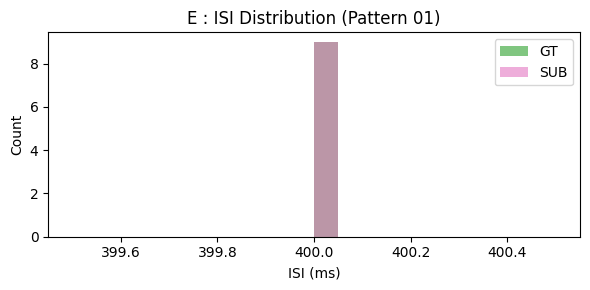


Neuron: E | Pattern: 10
  GT  - CV: 0.5289 | Fano: 0.0
  SUB - CV: 0.5289 | Fano: 0.0
  Wasserstein: 0.0000


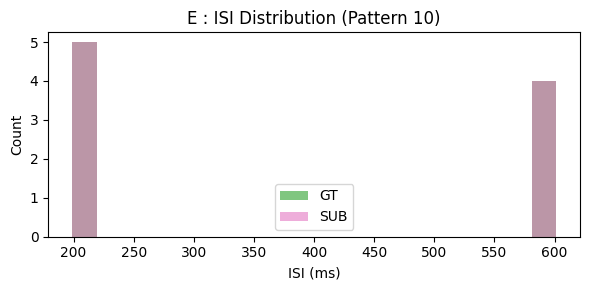


Neuron: Int_A | Pattern: 01
  GT  - CV: 0.0000 | Fano: 0.0
  SUB - CV: 0.0000 | Fano: 0.0
  Wasserstein: 0.0000


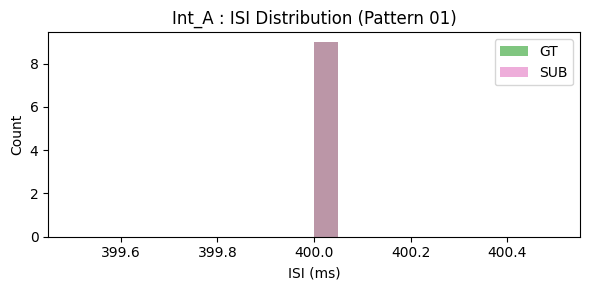


Neuron: Int_B | Pattern: 10
  GT  - CV: 0.5289 | Fano: 0.0
  SUB - CV: 0.5289 | Fano: 0.0
  Wasserstein: 0.0000


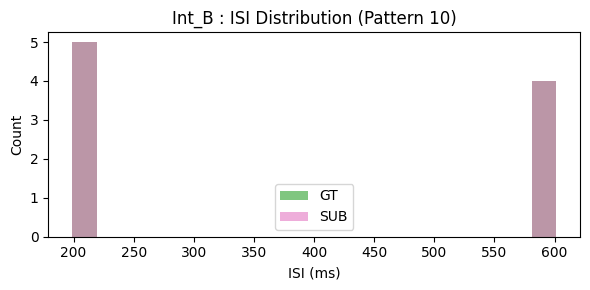


Neuron: PyrMid_A | Pattern: 11
  GT  - CV: 0.4730 | Fano: 0.0
  SUB - CV: 0.4730 | Fano: 0.0
  Wasserstein: 0.0000


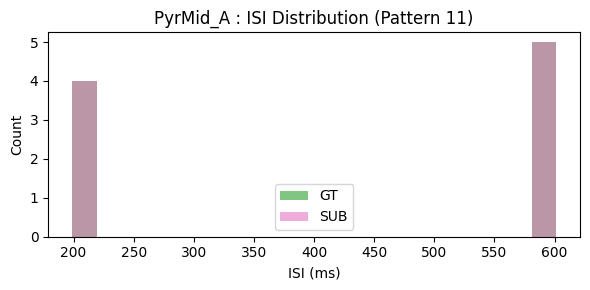


Neuron: PyrMid_A | Pattern: 01
  GT  - CV: 0.0025 | Fano: 0.0
  SUB - CV: 0.0025 | Fano: 0.0
  Wasserstein: 0.0000


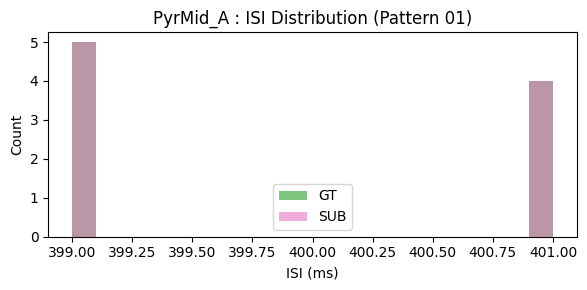


Neuron: PyrMid_B | Pattern: 11
  GT  - CV: 0.4708 | Fano: 0.0
  SUB - CV: 0.4708 | Fano: 0.0
  Wasserstein: 0.0000


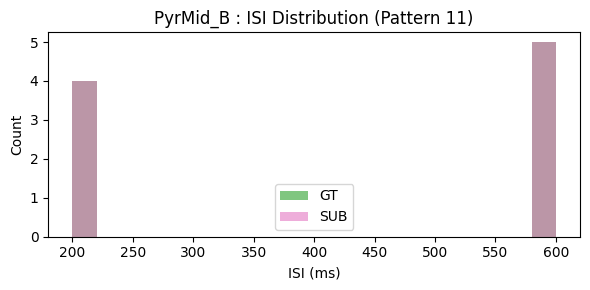


Neuron: PyrMid_B | Pattern: 10
  GT  - CV: 0.5261 | Fano: 0.0
  SUB - CV: 0.5261 | Fano: 0.0
  Wasserstein: 0.0000


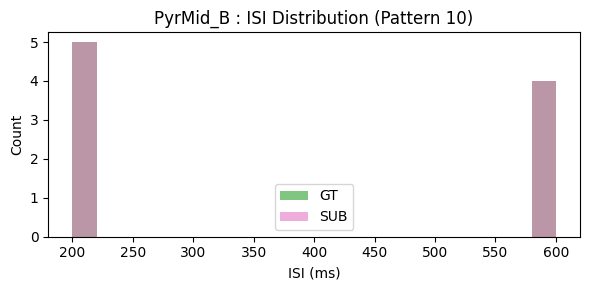


Neuron: PyrIn_B1 | Pattern: 11
  GT  - CV: 0.4708 | Fano: 0.0
  SUB - CV: 0.4708 | Fano: 0.0
  Wasserstein: 0.0000


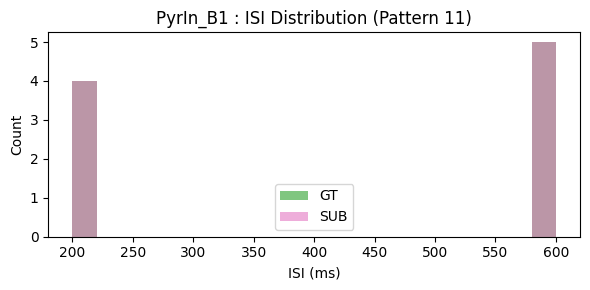


Neuron: PyrIn_B1 | Pattern: 01
  GT  - CV: 0.0000 | Fano: 0.0
  SUB - CV: 0.0000 | Fano: 0.0
  Wasserstein: 0.0000


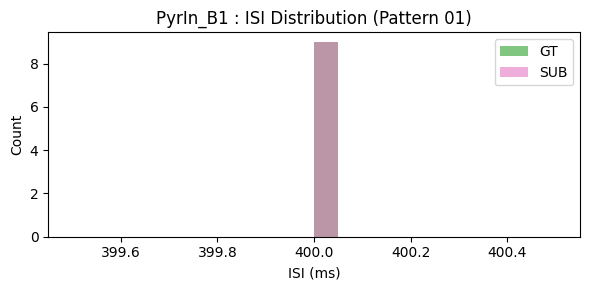


Neuron: PyrIn_A | Pattern: 11
  GT  - CV: 0.4708 | Fano: 0.0
  SUB - CV: 0.4708 | Fano: 0.0
  Wasserstein: 0.0000


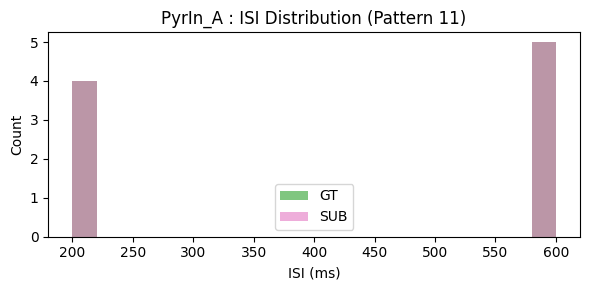


Neuron: PyrIn_A | Pattern: 10
  GT  - CV: 0.5261 | Fano: 0.0
  SUB - CV: 0.5261 | Fano: 0.0
  Wasserstein: 0.0000


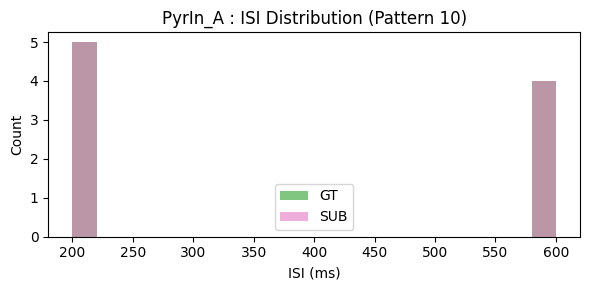


Neuron: PyrIn_B2 | Pattern: 11
  GT  - CV: 0.4708 | Fano: 0.0
  SUB - CV: 0.4708 | Fano: 0.0
  Wasserstein: 0.0000


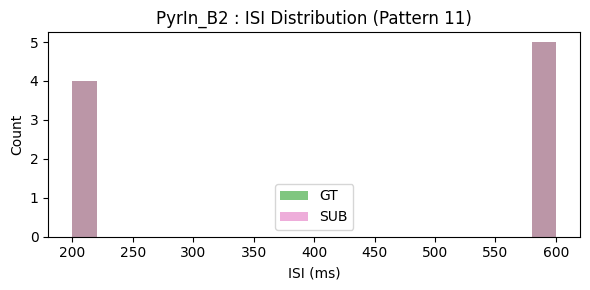


Neuron: PyrIn_B2 | Pattern: 01
  GT  - CV: 0.0000 | Fano: 0.0
  SUB - CV: 0.0000 | Fano: 0.0
  Wasserstein: 0.0000


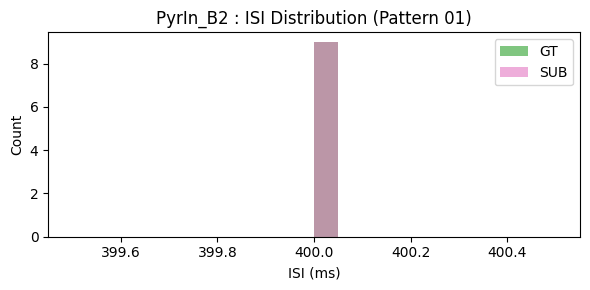

In [15]:
#ISI

try:
    from scipy.stats import wasserstein_distance
except Exception:
    wasserstein_distance = None

rows = []


def compute_isi_metrics(data_spikes,data, cfg, patterns, tmap):
    rows = []
    for neuron in get_spiking_neurons(cfg, data):
        for p in patterns:
            spike_times = data_spikes[
                (data_spikes["label"] == neuron) & 
                (data_spikes["pattern"] == p)
            ]["spike_time_ms"].to_numpy()
            
            all_reps = tmap[tmap["case"] == p]["rep"].unique()
            counts = data_spikes[
                (data_spikes["label"] == neuron) & 
                (data_spikes["pattern"] == p)
            ].groupby("rep").size().reindex(all_reps, fill_value=0).to_numpy()
            
            isi = np.diff(spike_times)
            
            cv   = np.std(isi) / np.mean(isi) if len(isi) > 0 else None
            fano = np.var(counts) / np.mean(counts) if np.mean(counts) > 0 else None
            
            rows.append({
                "neuron":  neuron,
                "pattern": p,
                "cv":      cv,
                "fano":    fano,
                "isi":     isi  # keep raw ISI for wasserstein + plotting later
            })
    return pd.DataFrame(rows)

gt_isi_stats = compute_isi_metrics(gt_spikes,gt_data,cfg,patterns, tmap)
sub_isi_stats = compute_isi_metrics(gt_spikes,sub_data,cfg,patterns, tmap)
print("GT Model")
print()
print(gt_isi_stats.to_string())
print()
print("SUB Model")
print()
print(sub_isi_stats.to_string())


def plot_isi(gt_isi_df, sub_isi_df):
    for neuron in gt_isi_df["neuron"].unique():
        for p in patterns:
            gt_row = gt_isi_df[(gt_isi_df["neuron"] == neuron) & (gt_isi_df["pattern"] == p)]
            sub_row = sub_isi_df[(sub_isi_df["neuron"] == neuron) & (sub_isi_df["pattern"] == p)]
            
            gt_isi = gt_row["isi"].values[0]
            sub_isi = sub_row["isi"].values[0]
            
            if len(gt_isi) == 0 and len(sub_isi) == 0:
                continue  #Skip that dont give results
            
            if len(gt_isi) > 0 and len(sub_isi) > 0:
                w = wasserstein_distance(gt_isi, sub_isi)
            else:
                w = None

            # print the data
            print(f"\nNeuron: {neuron} | Pattern: {p}")
            print(f"  GT  - CV: {gt_row['cv'].values[0]:.4f} | Fano: {gt_row['fano'].values[0]}")
            print(f"  SUB - CV: {sub_row['cv'].values[0]:.4f} | Fano: {sub_row['fano'].values[0]}")
            print(f"  Wasserstein: {w:.4f}" if w is not None else "  Wasserstein: N/A")
            # plot
            fig, ax = plt.subplots(figsize=(6, 3))
            if len(gt_isi) > 0:
                ax.hist(gt_isi, bins=20, alpha=0.6, label="GT", color="tab:green")
            if len(sub_isi) > 0:
                ax.hist(sub_isi, bins=20, alpha=0.6, label="SUB", color="tab:pink")
            
            ax.set_title(f"{neuron} : ISI Distribution (Pattern {p})")
            ax.set_xlabel("ISI (ms)")
            ax.set_ylabel("Count")
            ax.legend()
            plt.tight_layout()
            plt.show()


plot_isi(gt_isi_stats,sub_isi_stats)

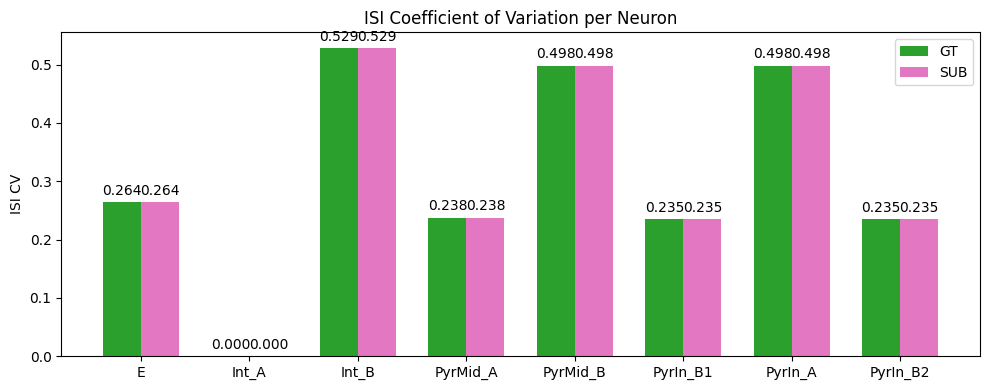

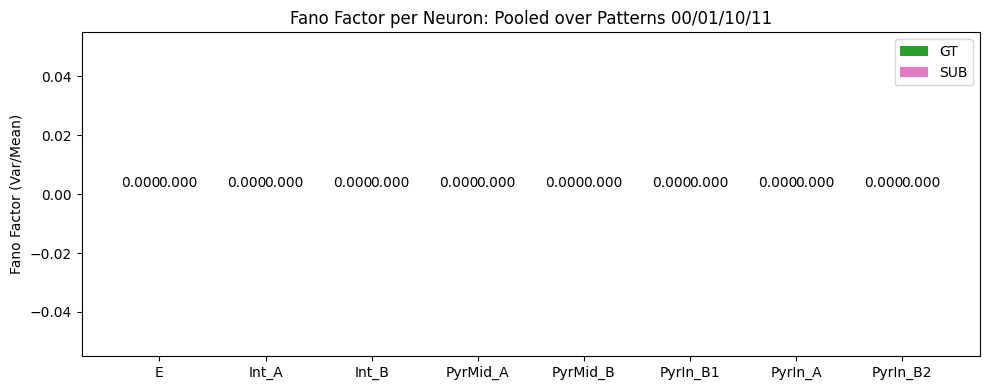

In [16]:
#Summary PLots for ISI and Fano Factor

def plot_isi_cv_summary(gt_isi_df, sub_isi_df):
    neurons = gt_isi_df["neuron"].unique()
    
    gt_cv  = [gt_isi_df[gt_isi_df["neuron"] == n]["cv"].dropna().mean() for n in neurons]
    sub_cv = [sub_isi_df[sub_isi_df["neuron"] == n]["cv"].dropna().mean() for n in neurons]
    
    x = np.arange(len(neurons))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    bars_gt  = ax.bar(x - width/2, gt_cv,  width, label="GT",  color="tab:green")
    bars_sub = ax.bar(x + width/2, sub_cv, width, label="SUB", color="tab:pink")
    
    ax.bar_label(bars_gt,  fmt="%.3f", padding=3)
    ax.bar_label(bars_sub, fmt="%.3f", padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(neurons)
    ax.set_ylabel("ISI CV")
    ax.set_title("ISI Coefficient of Variation per Neuron")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_fano_summary(gt_isi_df, sub_isi_df):
    neurons = gt_isi_df["neuron"].unique()
    
    gt_fano  = [gt_isi_df[gt_isi_df["neuron"] == n]["fano"].dropna().mean() for n in neurons]
    sub_fano = [sub_isi_df[sub_isi_df["neuron"] == n]["fano"].dropna().mean() for n in neurons]
    
    x = np.arange(len(neurons))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    bars_gt  = ax.bar(x - width/2, gt_fano,  width, label="GT",  color="tab:green")
    bars_sub = ax.bar(x + width/2, sub_fano, width, label="SUB", color="tab:pink")
    
    ax.bar_label(bars_gt,  fmt="%.3f", padding=3)
    ax.bar_label(bars_sub, fmt="%.3f", padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(neurons)
    ax.set_ylabel("Fano Factor (Var/Mean)")
    ax.set_title("Fano Factor per Neuron: Pooled over Patterns 00/01/10/11")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_isi_cv_summary(gt_isi_stats,sub_isi_stats)
plot_fano_summary(gt_isi_stats,sub_isi_stats)

Int_B_spike: KS=0.000, p=1.000


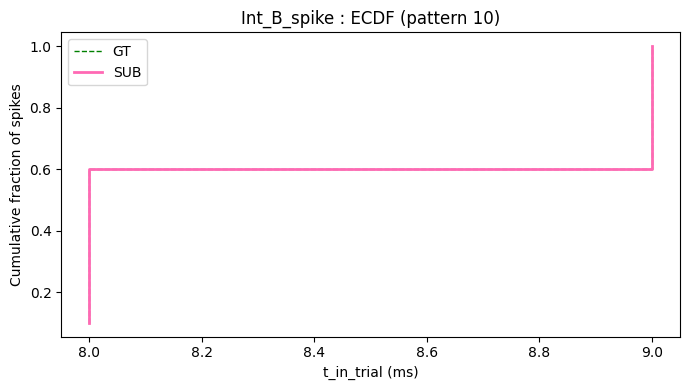

PyrMid_B_spike: KS=0.000, p=1.000


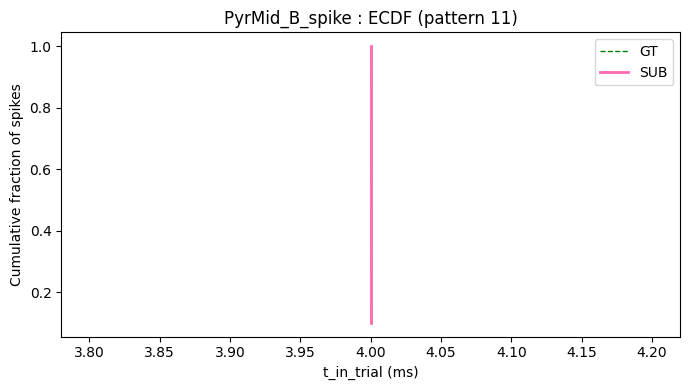

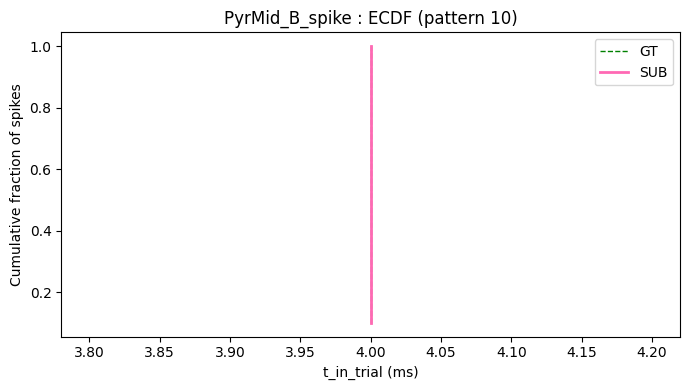

PyrIn_B2_spike: KS=0.000, p=1.000


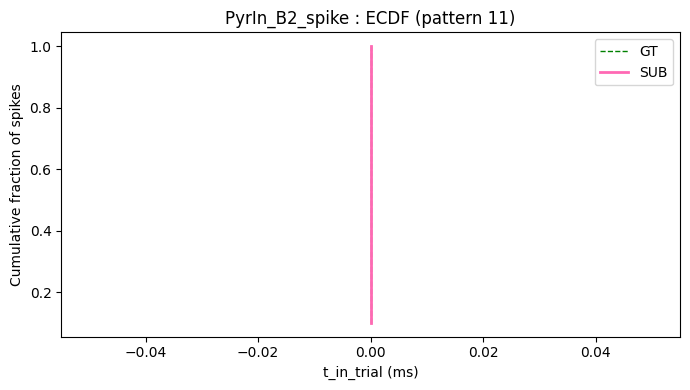

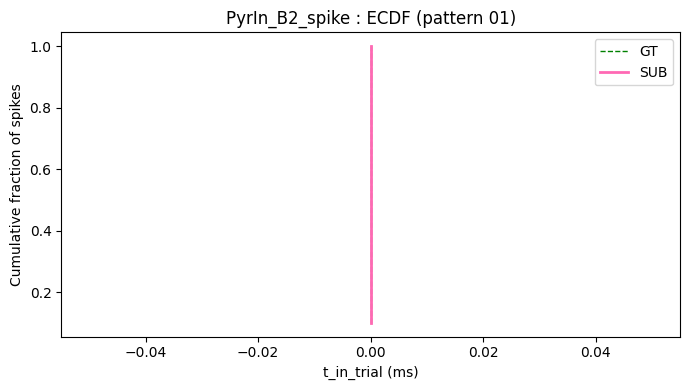

E_spike: KS=0.000, p=1.000


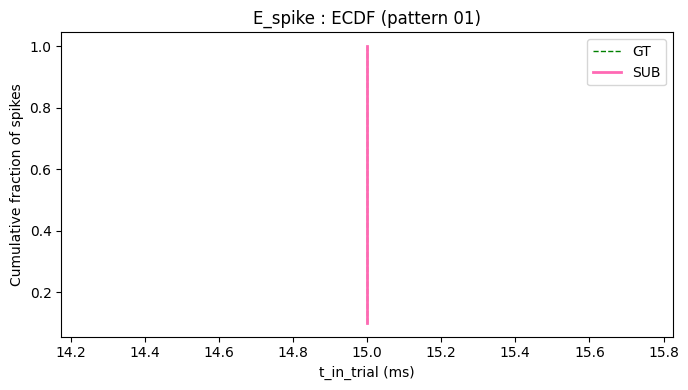

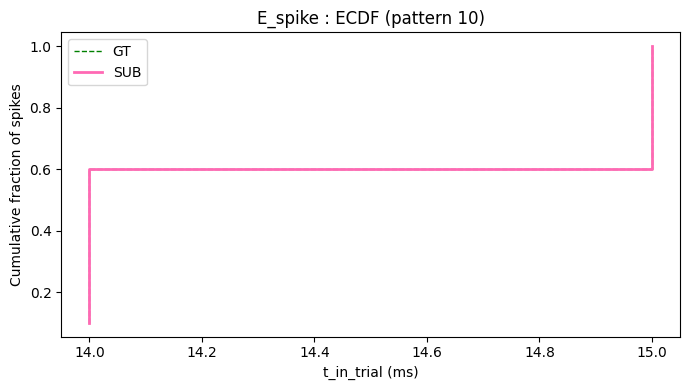

PyrMid_A_spike: KS=0.000, p=1.000


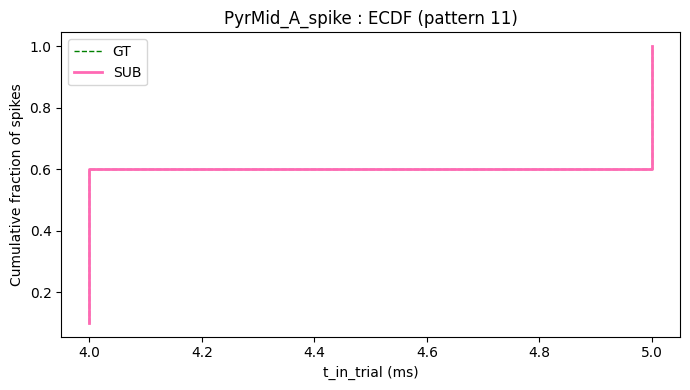

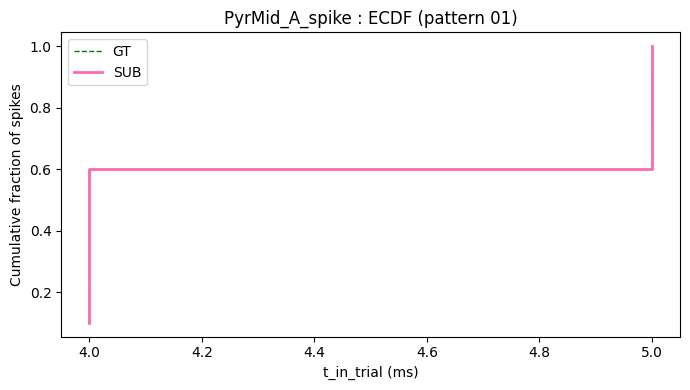

PyrIn_A_spike: KS=0.000, p=1.000


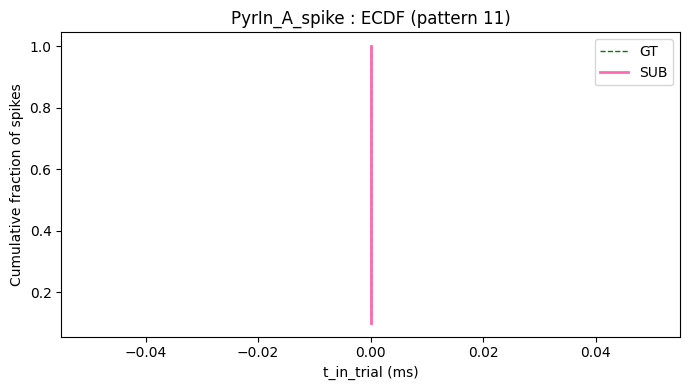

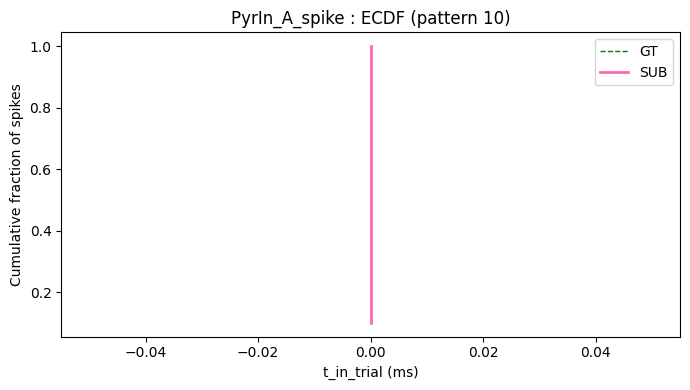

Int_A_spike: KS=0.000, p=1.000


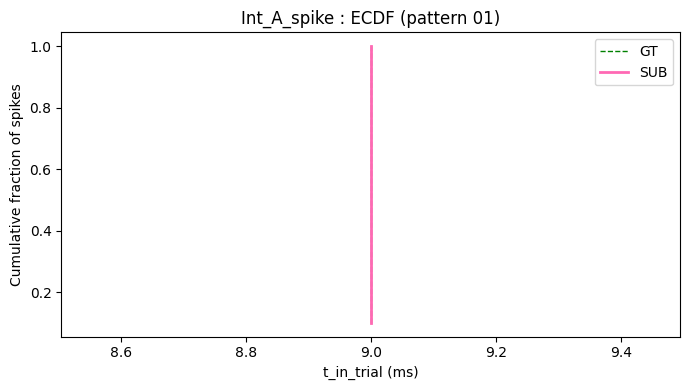

PyrIn_B1_spike: KS=0.000, p=1.000


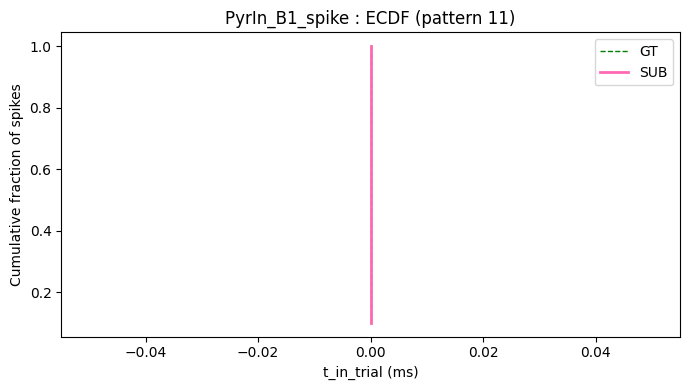

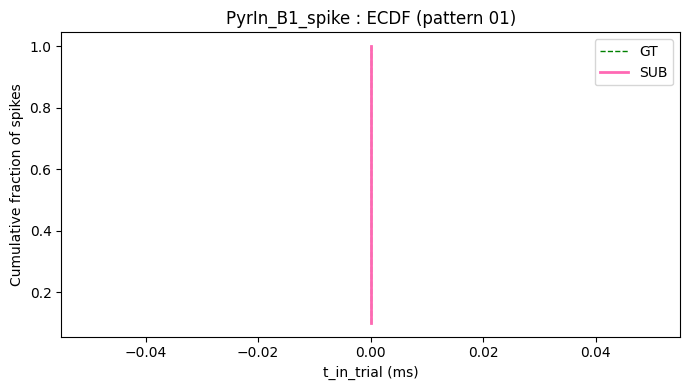

In [17]:
# KS Metric - Kolmogorov-Smirnov Test for Spike Time Distributions
from scipy.stats import ks_2samp

def plot_ecdf(gt_times, sub_times, neuron, pattern=None):
    # build ECDFs
    fig, ax = plt.subplots(figsize=(7, 4))
    
    if len(gt_times) > 0:
        gt_sorted  = np.sort(gt_times)
        gt_ecdf  = np.arange(1, len(gt_sorted)  + 1) / len(gt_sorted)
        ax.step(gt_sorted,  gt_ecdf,  label="GT",  color="green", lw=1.0, linestyle="--")

    if len(sub_times) > 0:
        sub_sorted = np.sort(sub_times)
        sub_ecdf = np.arange(1, len(sub_sorted) + 1) / len(sub_sorted)
        ax.step(sub_sorted, sub_ecdf, label="SUB", color="hotpink",   lw=2.0)
    
    ax.set_xlabel("t_in_trial (ms)")
    ax.set_ylabel("Cumulative fraction of spikes")
    title = f"{neuron} : ECDF"
    if pattern:
        title += f" (pattern {pattern})"
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

gt_spike_times = []
sub_spike_times = []
rows_pattern = []
for neuron in spike_cols:
    label = neuron.replace("_spike", "")
    gt_spike_times  = gt_spikes[gt_spikes["label"] == label]["t_in_trial"].to_numpy()
    sub_spike_times = sub_spikes[sub_spikes["label"] == label]["t_in_trial"].to_numpy()

    if len(gt_spike_times) > 0 and len(sub_spike_times) > 0:
        ks_stat, p_val = ks_2samp(gt_spike_times, sub_spike_times)
        print(f"{neuron}: KS={ks_stat:.3f}, p={p_val:.3f}")
    else:
        print(f"{neuron}: not enough spikes")

    for p in patterns:
        gt_times  = gt_spikes[(gt_spikes["label"] == label) & (gt_spikes["pattern"] == p)]["t_in_trial"].to_numpy()
        sub_times = sub_spikes[(sub_spikes["label"] == label) & (sub_spikes["pattern"] == p)]["t_in_trial"].to_numpy()
            
        if len(gt_times) > 0 and len(sub_times) > 0:
            ks_stat, p_val = ks_2samp(gt_times, sub_times)
        else:
            ks_stat, p_val = None, None
            
        rows_pattern.append({
                "neuron":     neuron,
                "pattern":    p,
                "gt_spikes":  len(gt_times),
                "sub_spikes": len(sub_times),
                "ks_stat":    ks_stat,
                "p_value":    p_val
        })

        if len(gt_times) == 0 and len(sub_times) == 0:
            continue  # skip silent patterns
            
        plot_ecdf(gt_times, sub_times, neuron, pattern=p)


In [12]:
# PSP Counts Metric - Peak detection in membrane potentials
from scipy.signal import find_peaks

In [ ]:
# VM Mismatch Metric - Membrane potential comparison and visualization

def build_tables_then_plot(gt_data,sub_data, dpi=130, verbose=True):
    vm_cols  = get_vm_cols(cfg, scope="all")
    patterns = tmap["case"].unique().tolist()
    trial_len = int(meta["trial_len_ms"])
    ms_per_sample = 1000.0 / meta["fs_hz"]

    def _trial_full_stats(gt_df, sb_df, vm_cols):
        """Compute full-trial mismatch statistics."""
        n = min(len(gt_df), len(sb_df))
        if n == 0:
            return {"neuron_col": None, "rms": 0.0, "peak": 0.0, "win_str": ""}

        win_str = f"0.0–{(n-1)*ms_per_sample:.1f}"

        best_col, best_rms, best_peak = None, 0.0, 0.0
        for col in vm_cols:
            if (col not in gt_df.columns) or (col not in sb_df.columns):
                continue
            g = gt_df[col].to_numpy(dtype=float)[:n]
            s = sb_df[col].to_numpy(dtype=float)[:n]
            d = g - s
            if d.size == 0:
                continue
            rms = float(np.sqrt(np.nanmean(d * d)))
            peak = float(np.nanmax(np.abs(d)))
            if rms > best_rms:
                best_rms = rms
                best_peak = peak
                best_col = col

        return {"neuron_col": best_col, "rms": best_rms, "peak": best_peak, "win_str": win_str}


    # Table 1: Worst trial per pattern
    p_rows = []
    for patt in patterns:
        ids = tmap[tmap["case"] == patt]["trial_id"].tolist()
        if not ids:
            continue
        scored = []
        for i in ids:
            s = _trial_full_stats(get_trial(gt_data, trial_id=i), get_trial(sub_data, trial_id=i), vm_cols)
            if s["neuron_col"] is None:
                continue
            scored.append((i, s))
        if not scored:
            continue
        trial_id, stat = max(scored, key=lambda x: x[1]["rms"])
        p_rows.append({
            "pattern": patt,
            "trial_id": int(trial_id),
            "Neuron_VM (worst)": stat["neuron_col"],
            "Best RMS Δ (mV)": float(stat["rms"]),
            "Peak |Δ| (mV)": float(stat["peak"]),
            "Window (ms)": stat["win_str"],
        })

    pattern_worst_table = pd.DataFrame(p_rows, columns=[
        "pattern", "trial_id", "Neuron_VM (worst)", "Best RMS Δ (mV)", "Peak |Δ| (mV)", "Window (ms)"
    ])

    # Table 2: Worst trial per neuron across all trials
    n_rows = []
    for col in vm_cols:
        best = {"trial": None, "patt": None, "rms": 0.0, "peak": 0.0, "win": ""}
        for i in range(len(tmap)):
            gt_df, sb_df = get_trial(gt_data, trial_id=i),get_trial(sub_data, trial_id=i)
            if (col not in gt_df.columns) or (col not in sb_df.columns):
                continue
            stat = _trial_full_stats(gt_df, sb_df, [col])
            if stat["neuron_col"] is None:
                continue
            if stat["rms"] > best["rms"]:
                best.update({
                    "trial": i,
                    "patt": tmap[tmap["trial_id"] == i]["case"].values[0],
                    "rms": float(stat["rms"]),
                    "peak": float(stat["peak"]),
                    "win": stat["win_str"]
                })

        if best["trial"] is None:
            n_rows.append({
                "Neuron_VM": col, "Best RMS Δ (mV)": 0.0, "Peak |Δ| (mV)": 0.0,
                "pattern": None, "trial_id": np.nan, "Window (ms)": ""
            })
        else:
            n_rows.append({
                "Neuron_VM": col, "Best RMS Δ (mV)": best["rms"], "Peak |Δ| (mV)": best["peak"],
                "pattern": best["patt"], "trial_id": int(best["trial"]), "Window (ms)": best["win"]
            })

    neuron_best_table = pd.DataFrame(n_rows, columns=[
        "Neuron_VM", "Best RMS Δ (mV)", "Peak |Δ| (mV)", "pattern", "trial_id", "Window (ms)"
    ])

    # Format floats
    def _fmt_float(x, nd=6):
        try:
            return float(f"{float(x):.{nd}g}")
        except:
            return x

    if not pattern_worst_table.empty:
        pattern_worst_table["Best RMS Δ (mV)"] = pattern_worst_table["Best RMS Δ (mV)"].map(lambda v: _fmt_float(v, 6))
        pattern_worst_table["Peak |Δ| (mV)"] = pattern_worst_table["Peak |Δ| (mV)"].map(lambda v: _fmt_float(v, 6))
        pattern_worst_table = pattern_worst_table.sort_values(["pattern"]).reset_index(drop=True)

    if not neuron_best_table.empty:
        neuron_best_table["Best RMS Δ (mV)"] = neuron_best_table["Best RMS Δ (mV)"].map(lambda v: _fmt_float(v, 6))
        neuron_best_table["Peak |Δ| (mV)"] = neuron_best_table["Peak |Δ| (mV)"].map(lambda v: _fmt_float(v, 6))
        neuron_best_table = neuron_best_table.sort_values(["Neuron_VM"]).reset_index(drop=True)

    # Print tables
    print("=== Membrane Potential — Mismatch (Pattern Worst Trial) ===")
    if pattern_worst_table.empty:
        print("(none)")
    else:
        print(pattern_worst_table.to_string(index=False))

    print("\n=== Membrane Potential — Mismatch (Best Across Trials per Neuron) ===")
    if neuron_best_table.empty:
        print("(none)")
    else:
        print(neuron_best_table.to_string(index=False))

    # Plot referenced trials
    def _plot_trial_fullstack(gt_df, sb_df, patt, trial_id, title_note, vm_cols, dpi=130):
        """Plot all VM traces for a trial."""
        n = min(len(gt_df), len(sb_df))
        if n == 0:
            return

        tt = gt_df["t_in_trial"].to_numpy(dtype=float)[:n]
        xlab = "Time in trial (ms)"

        ms0 = 0.0
        ms1 = float(meta["trial_len_ms"]) - 1.0

        rows = len(vm_cols)
        fig_h = max(2.2 * rows, 3.2)
        fig, axs = plt.subplots(rows, 1, figsize=(8.6, fig_h), sharex=True, dpi=dpi)
        if rows == 1:
            axs = [axs]

        for ax, c in zip(axs, vm_cols):
            if (c not in gt_df.columns) or (c not in sb_df.columns):
                ax.axis("off")
                continue
            g = gt_df[c].to_numpy(dtype=float)[:n]
            s = sb_df[c].to_numpy(dtype=float)[:n]
            ax.plot(tt, g, lw=1.6, label="GT")
            ax.plot(tt, s, lw=1.6, ls="--", label="SUB")
            ax.fill_between(tt, g, s, alpha=0.12)
            ax.set_ylabel("mV")
            ax.set_title(c, fontsize=9)
            ax.grid(alpha=0.25)

        axs[-1].set_xlabel(xlab)
        fig.suptitle(
            f"Pattern {patt} — Trial {trial_id} • table-selected | window ms [{ms0:.1f}–{ms1:.1f}] • {title_note}",
            fontsize=11
        )
        axs[0].legend(loc="upper right", fontsize=9)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # Collect unique trials to plot
    to_plot = set()
    for df in (pattern_worst_table, neuron_best_table):
        if not df.empty:
            for _, r in df.iterrows():
                patt = r.get("pattern", None)
                tid = r.get("trial_id", None)
                if pd.notna(patt) and pd.notna(tid):
                    to_plot.add((str(patt), int(tid)))

    def _ids_for_pattern(patt):
        return set(tmap[tmap["case"] == patt]["trial_id"].tolist())

    if not to_plot and verbose:
        print("\n[vm-plot] No valid trials in tables — nothing to plot.")
    else:
        grouped = {}
        for patt, tid in to_plot:
            grouped.setdefault(patt, set()).add(tid)

        for patt, tids in sorted(grouped.items()):
            common = _ids_for_pattern(patt)
            valid_ids = [tid for tid in sorted(tids) if tid in common]
            if not valid_ids:
                if verbose:
                    print(f"\n[vm-plot] pattern {patt}: no valid table-selected trials — skipped.")
                continue

            if verbose:
                print(f"\n[vm-plot] pattern {patt}: plotting {len(valid_ids)} table-selected trial(s)")
            for tid in valid_ids:
                gt_trial  = get_trial(gt_data,  trial_id=tid)
                sub_trial = get_trial(sub_data, trial_id=tid)

                stat = _trial_full_stats(gt_trial, sub_trial, vm_cols)
                note = f"worst-neuron={stat['neuron_col']} • peak|Δ|={stat['peak']:.3f} mV • rmsΔ={stat['rms']:.3f} mV"
                _plot_trial_fullstack(gt_trial, sub_trial, patt, tid, note, vm_cols, dpi=dpi)
    return {"pattern_worst_table": pattern_worst_table, "neuron_best_table": neuron_best_table}

# Execute
out = build_tables_then_plot(gt_data,sub_data, dpi=130, verbose=True)

=== Membrane Potential — Mismatch (Pattern Worst Trial) ===
(none)

=== Membrane Potential — Mismatch (Best Across Trials per Neuron) ===
   Neuron_VM  Best RMS Δ (mV)  Peak |Δ| (mV) pattern  trial_id Window (ms)
        E_vm              0.0            0.0    None       NaN            
    Int_A_vm              0.0            0.0    None       NaN            
    Int_B_vm              0.0            0.0    None       NaN            
  PyrIn_A_vm              0.0            0.0    None       NaN            
 PyrIn_B1_vm              0.0            0.0    None       NaN            
 PyrIn_B2_vm              0.0            0.0    None       NaN            
 PyrMid_A_vm              0.0            0.0    None       NaN            
 PyrMid_B_vm              0.0            0.0    None       NaN            
 neuron_0_vm              0.0            0.0    None       NaN            
neuron_10_vm              0.0            0.0    None       NaN            
neuron_11_vm              0.0        

In [ ]:
# Cross Correlogram Metric - Binary cross-correlation analysis

spike_cols = list(set(get_spike_cols(cfg, gt_data)) | set(get_spike_cols(cfg, sub_data)))

# def _resp_window_ms(meta_row):
#     """Get response window in ms."""
#     rw = meta_row.get("response_window")
#     if rw is None:
#         return int(RESP_LO_MS), int(RESP_HI_MS)
#     lo, hi = int(rw[0]), int(rw[1])
#     return max(0, lo), max(lo + 1, hi)

# def _resp_window_idx(df, meta_row):
#     """Convert response window from ms to sample indices."""
#     lo_ms, hi_ms = _resp_window_ms(meta_row)
#     n = len(df)
#     if n == 0:
#         return 0, 0

#     if "time" in df.columns:
#         t = df["time"].to_numpy(float)
#         lo_idx = int(np.searchsorted(t, lo_ms, side="left"))
#         hi_idx = int(np.searchsorted(t, hi_ms, side="right"))
#     else:
#         lo_idx, hi_idx = lo_ms, hi_ms

#     lo_idx = max(0, min(lo_idx, n))
#     hi_idx = max(lo_idx + 1, min(hi_idx, n))
#     return lo_idx, hi_idx

# def _seg_bin(df, col, lo_idx, hi_idx):
#     """Extract binary segment from column."""
#     if (col not in df.columns) or lo_idx >= hi_idx:
#         return np.zeros(0, dtype=np.int8)
#     arr = df[col].to_numpy(int, copy=False)
#     hi_idx = min(hi_idx, len(arr))
#     return arr[lo_idx:hi_idx].astype(np.int8, copy=False)

# def _xcorr_norm(a, b, max_lag):
#     """Normalized binary cross-correlation."""
#     if a.size == 0 or b.size == 0:
#         lags = np.arange(-max_lag, max_lag + 1, dtype=int)
#         return lags, np.zeros(lags.size, dtype=float)

#     W = int(min(a.size, b.size))
#     if W <= 1:
#         lags = np.arange(-max_lag, max_lag + 1, dtype=int)
#         return lags, np.zeros_like(lags, dtype=float)

#     L = int(min(max_lag, W - 1))
#     full = np.correlate(a.astype(float), b.astype(float), mode="full")
#     l_full = np.arange(-(W - 1), (W - 1) + 1, dtype=int)
#     sel = (l_full >= -L) & (l_full <= L)
#     lags = l_full[sel]
#     counts = full[sel].astype(float)
#     eff = (W - np.abs(lags)).astype(float)
#     eff[eff <= 0] = np.nan
#     cc = counts / eff
#     cc = np.where(np.isfinite(cc), cc, 0.0)
#     return lags, cc

# def _avg_ccg_trials(trials_i, trials_j, meta, col_i, col_j, max_lag):
#     """Average CCG across trials."""
#     curves = []
#     for df_i, df_j, m in zip(trials_i, trials_j, meta):
#         lo, hi = _resp_window_idx(df_i, m)
#         ai = _seg_bin(df_i, col_i, lo, hi)
#         bj = _seg_bin(df_j, col_j, lo, hi)
#         lags, cc = _xcorr_norm(ai, bj, max_lag)
#         curves.append(cc)

#     if not curves:
#         lags = np.arange(-max_lag, max_lag + 1, dtype=int)
#         mean_cc = np.zeros_like(lags, dtype=float)
#     else:
#         mean_cc = np.nanmean(np.vstack(curves), axis=0)
#     return lags, mean_cc

# def _ccg_matrix_for_pattern(trials_block, meta_block, spike_cols, title, max_lag=MAX_LAG_MS):
#     """Create CCG matrix plot for pattern."""
#     n = len(spike_cols)
#     if n == 0 or not trials_block:
#         return None, np.nan

#     lags = np.arange(-max_lag, max_lag + 1, dtype=int)
#     fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n), sharex=True, sharey=True)
#     if n == 1:
#         axes = np.array([[axes]])

#     zero_vals = []
#     for i, ci in enumerate(spike_cols):
#         for j, cj in enumerate(spike_cols):
#             _, cc = _avg_ccg_trials(trials_block, trials_block, meta_block, ci, cj, max_lag)
#             ax = axes[i, j]
#             ax.bar(lags, cc, width=1)
#             ax.axvline(0, color="red", ls="--", lw=1)
#             if i == n - 1:
#                 ax.set_xlabel(f"Lag (ms)\n{cj}")
#             if j == 0:
#                 ax.set_ylabel(f"{ci}\nCoincidence (norm)")
#             if i != j:
#                 zero_vals.append(cc[max_lag])

#     fig.suptitle(title, fontsize=14)
#     fig.tight_layout(rect=[0, 0, 1, 0.95])
#     mean_zero = float(np.nan) if not zero_vals else float(np.nanmean(zero_vals))
#     return fig, mean_zero


# def render_ccg_grids_like_old():
#     """Generate CCG matrices and summary statistics."""
#     rows, figs = [], []

#     for patt in patterns:
#         ids = ids = tmap[tmap["case"] == patt]["trial_id"].tolist()
#         if not ids:
#             continue

#         gt_trials_p = [gt_data(gt_data, trial_id=i) for i in ids]
#         sb_trials_p = [sub_data(sub_data, trial_id=i) for i in ids]

#         fig_gt, mean0_gt = _ccg_matrix_for_pattern(
#             gt_trials_p, gt_meta_p, spike_cols,
#             title=f"Cross Correlogram — Ground Truth (Concatenated-style) — Pattern {patt}",
#             max_lag=MAX_LAG_MS
#         )
#         fig_sb, mean0_sb = _ccg_matrix_for_pattern(
#             sb_trials_p, sb_meta_p, spike_cols,
#             title=f"Cross Correlogram — Submission (Concatenated-style) — Pattern {patt}",
#             max_lag=MAX_LAG_MS
#         )

#         if fig_gt is not None:
#             figs.append(fig_gt)
#         if fig_sb is not None:
#             figs.append(fig_sb)

#         rows.append(dict(
#             Pattern=patt,
#             MeanZeroLag_GT=mean0_gt,
#             MeanZeroLag_SUB=mean0_sb,
#             Delta_SUB_minus_GT=(mean0_sb - mean0_gt) if (np.isfinite(mean0_gt) and np.isfinite(mean0_sb)) else np.nan
#         ))

#     return pd.DataFrame(rows, columns=["Pattern", "MeanZeroLag_GT", "MeanZeroLag_SUB", "Delta_SUB_minus_GT"]), figs

# # Run and display results
# ccg_summary_like_old, ccg_figs_like_old = render_ccg_grids_like_old()

# # Print summary table
# print("\n=== CCG (old-report style) — Mean zero-lag summary ===")
# if not ccg_summary_like_old.empty:
#     print(ccg_summary_like_old.to_string(index=False))
# else:
#     print("(no patterns)")

# # Display figures
# for f in ccg_figs_like_old:
#     display(f)
#     plt.close(f)

In [ ]:
# Van Rossum Distance Metric - Spike train comparison with exponential kernel

In [ ]:
# Multi-Scale Correlation Metric - Correlation across time scales

In [ ]:
# Granger Causality Metric - Directional connectivity analysis

In [ ]:
# Schreiber Similarity Metric - Gaussian-smoothed spike trains